In [1]:
import os
import sys
import h5py
import yaml
import types
import torch
import numpy as np
# from sklearn.preprocessing import StandardScaler
# from sklearn.decomposition import PCA
# from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [2]:
REPO_ROOT = os.path.abspath("..")
sys.path.insert(0, REPO_ROOT)

from models.beta_vae import BetaVAE
from utils import make_run_tag
from data_utils import build_encode_dataloader

## Load IT neuron firing rate

In [3]:
neural_data_pth = os.path.join(REPO_ROOT, 'data/forJhan/data/MergedITCells_500Stim_AxisTuned.mat')

with h5py.File(neural_data_pth, 'r') as f:
    responses = f['responses']
    # Build full (386 x 500) matrix once
    neural_matrix = np.stack([f[responses[0, i]][()].flatten() for i in range(386)])  # (386, 500)

In [3]:
# X = neural_matrix.T  # (500 images, 386 neurons) — cluster images

# # --- Normalize: z-score each neuron across images ---
# X = StandardScaler().fit_transform(X)  # (500, 386)

# # --- PCA for dimensionality reduction before clustering ---
# pca = PCA(n_components=50)
# X_pca = pca.fit_transform(X)  # (500, 50)
# print(f"Variance explained by 50 PCs: {pca.explained_variance_ratio_.sum():.2%}")

In [1]:
# # --- K-Means clustering ---
# n_clusters = 6
# kmeans = KMeans(n_clusters=n_clusters, n_init=20, random_state=0)
# labels = kmeans.fit_predict(X_pca)  # (500,) cluster label per image

In [2]:
# # --- Visualize in 2D PCA space ---
# plt.figure(figsize=(7, 6))
# scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', s=20, alpha=0.8)
# plt.colorbar(scatter, label='Cluster')
# plt.xlabel('PC1'); plt.ylabel('PC2')
# plt.title('Neural response clusters (500 images)')
# plt.tight_layout()

## Encode stimuli images

### Load beta VAE

In [4]:
# CKPT_PATH = None # None → load latest checkpoint from experiment output dir
# CONFIG_PATH = "config/betavae_full_stimuli.yaml"   # relative to repo root

In [5]:
# with open(os.path.join(REPO_ROOT, CONFIG_PATH)) as f:
#     cfg = types.SimpleNamespace(**yaml.safe_load(f))

# cfg.output_dir = os.path.join(REPO_ROOT, f"{cfg.output_dir.lstrip('./')}_{make_run_tag(cfg)}")

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# model = BetaVAE(
#     input_channels=cfg.input_channels,
#     input_height=cfg.input_height,
#     input_width=cfg.input_width,
#     latent_dim=cfg.latent_dim,
#     hidden_dim=cfg.hidden_dim,
#     beta=cfg.beta,
#     device=device,
# )

# if CKPT_PATH is None:
#     ckpt_dir = os.path.join(cfg.output_dir, "checkpoints")
#     CKPT_PATH = os.path.join(ckpt_dir, "best_ckpt.pt")
#     if not os.path.exists(CKPT_PATH):
#         raise FileNotFoundError(f"best_ckpt.pt not found in {ckpt_dir}")

# ckpt = torch.load(CKPT_PATH, map_location=device)
# model.load_state_dict(ckpt["model_state_dict"])
# model.eval()
# print(f"Loaded: {CKPT_PATH}  (step {ckpt['step']})")

### Load stimuli images

In [6]:
# encode_data_path = os.path.join(REPO_ROOT, "data/500Stimuli")
# encode_dl = build_encode_dataloader(encode_data_path, image_size=cfg.input_height, batch_size=64)

### Forward pass

In [7]:
# all_mu = []
# with torch.no_grad():
#     for batch in encode_dl:
#         batch = batch.to(device)
#         _, mu, _ = model(batch)
#         all_mu.append(mu.cpu())

# all_mu = torch.cat(all_mu, dim=0).numpy()  # [N, latent_dim]
# print(f"Collected μ for {all_mu.shape[0]} images across {all_mu.shape[1]} latent dimensions")

In [8]:
alexnet_fc6_latents = np.load(os.path.join(REPO_ROOT, "data/stimuli_alexnet_fc6_pca_latents/val_latents.npy"))

In [10]:
alexnet_fc6_latents.shape

(500, 50)

## Regression

In [11]:
# from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

In [23]:
X = neural_matrix.T  # (500, 386) — samples × neurons
Y = alexnet_fc6_latents           # (500, 12)  — samples × latent dims

# X = alexnet_fc6_latents  # (500, 50) — samples × latent dims
# Y = neural_matrix.T           # (500, 386) — samples × neurons

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

In [24]:
ridge = RidgeCV(alphas=np.logspace(-1, 4, 20), cv=5)
ridge.fit(X_train_s, Y_train)

Y_pred = ridge.predict(X_test_s)
r2_per_dim = r2_score(Y_test, Y_pred, multioutput='raw_values')

print(f"Alpha: {ridge.alpha_:.2f}")
print(f"R² per latent dim: {np.round(r2_per_dim, 3)}")
print(f"Mean R²: {r2_per_dim.mean():.3f}")

Alpha: 885.87
R² per latent dim: [ 0.597  0.276  0.525  0.366  0.558  0.223  0.289  0.316  0.452  0.404
  0.139  0.252  0.267  0.132  0.324  0.295  0.125  0.186  0.163  0.038
  0.059  0.086  0.053  0.038  0.121  0.084  0.063  0.085  0.13   0.037
 -0.014  0.048  0.138  0.097  0.134 -0.004 -0.01  -0.021  0.031  0.166
  0.016  0.041 -0.044  0.017 -0.066  0.024 -0.045 -0.042  0.133 -0.053]
Mean R²: 0.145


In [26]:
# pls = PLSRegression(n_components=20)  # tune n_components
# pls.fit(X_train_s, Y_train)
# r2_per_dim = r2_score(Y_test, pls.predict(X_test_s), multioutput='raw_values')

# print(f"R² per latent dim: {np.round(r2_per_dim, 3)}")
# print(f"Mean R²: {r2_per_dim.mean():.3f}")

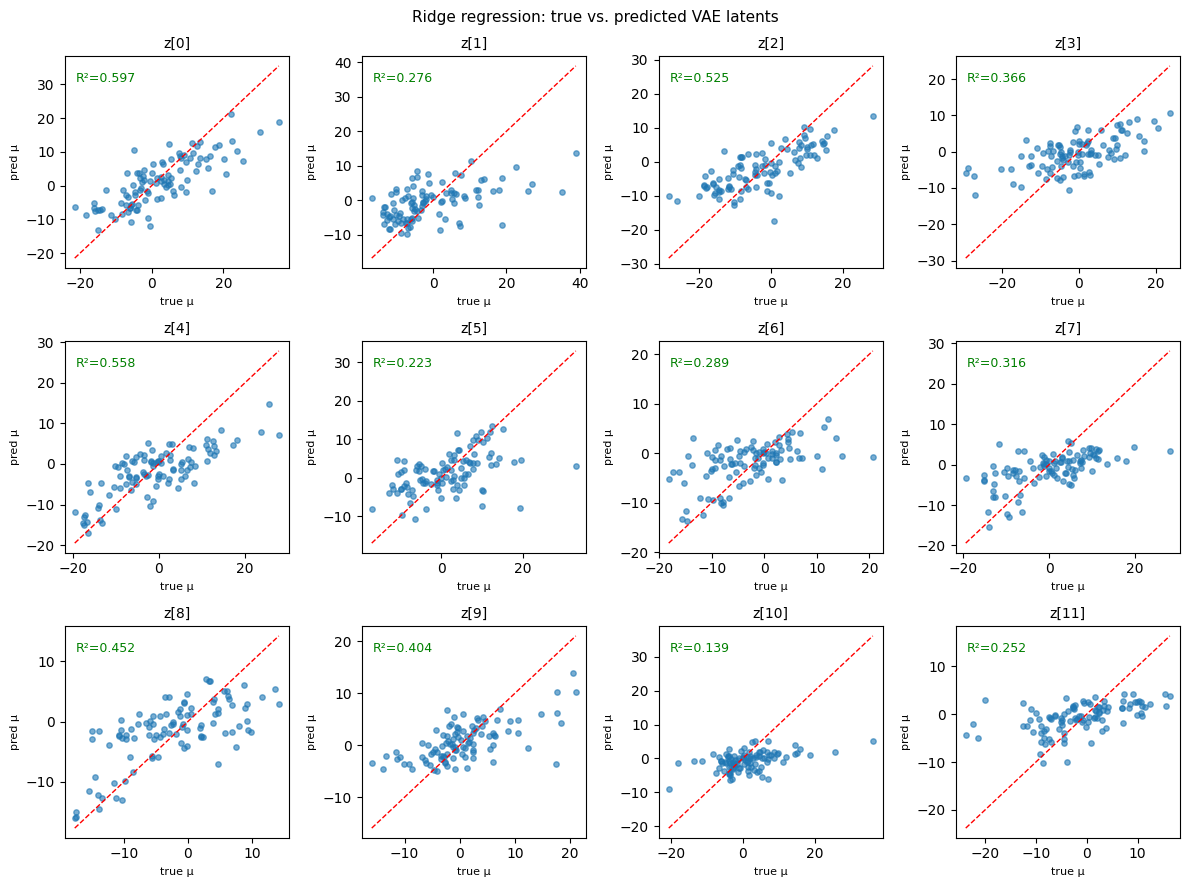

In [16]:
ncols = 4
nrows = (12 + ncols - 1) // ncols  # 3 rows

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3))
axes = axes.flatten()

for i in range(12):
    ax = axes[i]
    ax.scatter(Y_test[:, i], Y_pred[:, i], s=15, alpha=0.6)

    lo = min(Y_test[:, i].min(), Y_pred[:, i].min())
    hi = max(Y_test[:, i].max(), Y_pred[:, i].max())
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1)

    ax.set_title(f"z[{i}]", fontsize=10)
    ax.set_xlabel("true μ", fontsize=8)
    ax.set_ylabel("pred μ", fontsize=8)
    ax.annotate(f"R²={r2_per_dim[i]:.3f}", xy=(0.05, 0.88),
                xycoords='axes fraction', fontsize=9,
                color='green' if r2_per_dim[i] > 0.1 else 'red')

for i in range(12, len(axes)):
    axes[i].set_visible(False)

plt.suptitle("Ridge regression: true vs. predicted VAE latents", fontsize=11)
plt.tight_layout()
plt.show()